In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report
import re
import xgboost as xgb
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight
import itertools

In [2]:
#ruta donde se encuentra el dataset

In [3]:
ruta=

#### Lee dataset

In [5]:
df = pd.read_csv(ruta+'procesos2016_2022_nuevas_var_disc_ipc.csv', sep='|',low_memory=False)

In [6]:
metricas = pd.read_csv(ruta+'proceso_propiedades_grafo.csv', sep=',',low_memory=False);

In [7]:
def limpiar_numero(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["sin datos", "-", "", "nan"]:
        return np.nan   
    x = re.sub(r"[^\d.]", "", x)   # elimina letras y símbolos
    return pd.to_numeric(x, errors="coerce")

In [8]:
#construir la clase
#si el estado es Adjudicado, el proceso es exitoso, clase es 1
#si el estado es Desierto ó Dejado Sin Efecto, es no exitoso, clase es 0

df["targetB"] = (df["estado"] != "Adjudicado").astype(int)
# Crear el mapeo de estados a números
mapa_target = {
    "Adjudicado": 0,
    "Desierto": 1,
    "Dejado Sin Efecto": 2
}

# Crear la variable target usando map()
df["target"] = df["estado"].map(mapa_target)

In [9]:
#se seleccionan las variables a utilizar del dataset
num_features=['cro_cant_dias_publicar','periodo_apertura','periodo_publicacion',
'periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura',
'dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias','TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER',
'TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION',
'TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS',
'TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA']

In [ ]:
df[num_features] = df[num_features].applymap(limpiar_numero)

In [11]:
num_sin_tot_features=['cro_cant_dias_publicar','periodo_apertura','periodo_publicacion',
'periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura',
'dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias'
]

In [ ]:
df[num_sin_tot_features] = df[num_sin_tot_features].applymap(limpiar_numero)

In [13]:
cat_features = ['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion']


In [14]:
df_num = df[num_features]


In [15]:
df_num.dtypes

cro_cant_dias_publicar                 float64
periodo_apertura                         int64
periodo_publicacion                    float64
periodo_inicio_consultas               float64
periodo_final_consultas                float64
periodo_inicio_recepcion_documentos    float64
periodo_fin_recepcion_documentos       float64
periodo_acto_apertura                  float64
dias_recepción_doc_soporte_fisico      float64
duracion_contrato_dias                 float64
TOT_AGROPECUARIO                       float64
TOT_ALIMENTOS                          float64
TOT_ALQUILER                           float64
TOT_ART_HOGAR                          float64
TOT_BANCO                              float64
TOT_BAZAR                              float64
TOT_CARPINTERIA                        float64
TOT_CEREMONIAL                         float64
TOT_CERRAJERIA                         float64
TOT_CINE                               float64
TOT_COMBUSTIBLES                       float64
TOT_CONCESION

#### Se arman conjuntos de train y test

In [17]:
periodo_entrenamiento = 202112  # Último mes de entrenamiento
# Definir el periodo de prueba entre enero de 2020 (202001) y diciembre de 2022 (202212)
periodo_prueba_inicio = 202201  # Primer mes de prueba
periodo_prueba_fin = 202212    # Último mes de prueba

In [18]:
df_final = pd.concat([
    df[num_features],
    df[cat_features],
    df['target']
], axis=1)

In [19]:
#Convertir tus columnas a category
for col in cat_features:
    df_final[cat_features] = df_final[cat_features].astype("category")

In [22]:
# Filtrar los datos para entrenamiento (hasta diciembre de 2021)
df_train = df_final[df_final['periodo_apertura'] <= periodo_entrenamiento]

# Filtrar los datos para prueba (de enero de 2020 a diciembre de 2022)
df_test = df_final[(df_final['periodo_apertura'] >= periodo_prueba_inicio) & (df_final['periodo_apertura'] <= periodo_prueba_fin)]
# Verificar tamaños
print(f'Tamaño del conjunto de entrenamiento: {df_train.shape}')
print(f'Tamaño del conjunto de prueba: {df_test.shape}')

Tamaño del conjunto de entrenamiento: (55476, 78)
Tamaño del conjunto de prueba: (14210, 78)


In [23]:
y_train = df_train['target']
df_train=df_train.drop(columns=["target"])

y_test = df_test['target']
df_test=df_test.drop(columns=["target"])

In [24]:
y_train

0        0
1        1
2        0
3        0
4        0
        ..
55471    1
55472    1
55473    1
55474    1
55475    1
Name: target, Length: 55476, dtype: int64

In [25]:
#Como las clases son desbalanceadas
#se Calculan los pesos inversamente proporcionales a la frecuencia
class_counts = y_train.value_counts()
total = len(y_train)

# peso = total / (num_clases * frecuencia_clase)
class_weights = {}
for c, count in class_counts.items():
    weight = total / (len(class_counts) * count)

    # Multiplicar peso de clases 1 y 2 
    if c in [1, 2]:
        weight *= 1.1

    class_weights[c] = weight
        
#Pasar los pesos a cada fila
sample_weights = y_train.map(class_weights)

class_weights

{0: 0.4299965120334845, 2: 1.82514131897712, 1: 15.34027149321267}

In [26]:
#XGBoost incluye su propia clase para almacenar conjuntos de datos, llamada DMatrix. 
#Es una clase muy optimizada en cuanto a memoria y velocidad. 
#Por eso, convertir conjuntos de datos a este formato es un requisito para la API nativa de XGBoost

dtrain = xgb.DMatrix(
    df_train,
    label=y_train,
    weight=sample_weights,
    enable_categorical=True
)

dtest = xgb.DMatrix(
    df_test,
    label=y_test,
    enable_categorical=True
)


In [27]:
param_grid = {
    "max_depth":[3, 5], # [3, 4, 5] Profundidad máxima de los árboles.
    "min_child_weight": [1, 3, ], # [1, 3, 5] #Mínima suma de pesos (o número de instancias) necesaria para hacer un split.
    "subsample": [ 0.8, 1.0],#[0.6, 0.8, 1.0] Porcentaje de filas usadas en cada árbol.
    "colsample_bytree": [0.8, 1.0],#[0.6, 0.8, 1.0] Porcentaje de columnas usadas en cada árbol.
    "eta": [ 0.05, 0.1], #[0.01, 0.05, 0.1] #Qué tan rápido “aprende” el modelo. learning rate
    "gamma": [0, 0.1, 0.3] #Requerimiento mínimo de reducción de pérdida para permitir un split
}

base_params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "tree_method": "hist",
    "eval_metric": "mlogloss"
}

In [28]:
best_score = np.inf
best_params = None

# Calcular total de combinaciones
total_trials = np.prod([len(v) for v in param_grid.values()])

print(f"Total de combinaciones a evaluar: {total_trials}")

trial = 0

for values in itertools.product(*param_grid.values()):
    trial += 1

    params = dict(zip(param_grid.keys(), values))
    params.update(base_params)

    print(f"\nEjecutando combinación {trial}/{total_trials}: {params}")

    try:
        cv_results = xgb.cv(
            params=params,
            dtrain=dtrain,
            num_boost_round=500,
            nfold=5,
            metrics=["mlogloss"],
            early_stopping_rounds=20,
            verbose_eval=False
        )
    except Exception as e:
        print(f"Error en combinación {params}: {e}")
        continue

    mean_mlogloss = cv_results["test-mlogloss-mean"].iloc[-1]

    print(f" → mlogloss = {mean_mlogloss:.5f}")

    if mean_mlogloss < best_score:
        best_score = mean_mlogloss
        best_params = params
        print("   *** Nuevo mejor modelo encontrado ***")

print("\n===================================")
print("Mejores parámetros:", best_params)
print("Mejor CV mlogloss:", best_score)


Total de combinaciones a evaluar: 96

Ejecutando combinación 1/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.96729
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 2/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.1, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.96726
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 3/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.3, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.96722
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 4/96: {'max_depth': 3, 'min_child_weight'

In [64]:
best_params

{'max_depth': 3,
 'min_child_weight': 1,
 'subsample': 1.0,
 'colsample_bytree': 0.8,
 'eta': 0.1,
 'gamma': 0,
 'objective': 'multi:softprob',
 'num_class': 3,
 'tree_method': 'hist',
 'eval_metric': 'mlogloss'}

In [37]:
# Definir los parámetros óptimos para el modelo
best_params = {
 'max_depth': 5,
 'min_child_weight': 3,
 'subsample': 1.0,
 'colsample_bytree': 0.8,
 'eta': 0.05,
 'gamma': 0,
 'objective': 'multi:softprob',
 'num_class': 3,
 'tree_method': 'hist',
 'eval_metric': 'mlogloss'
}


In [65]:
model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=50
)



[0]	train-mlogloss:1.06811	test-mlogloss:1.09280
[50]	train-mlogloss:0.68457	test-mlogloss:0.96615
[100]	train-mlogloss:0.57868	test-mlogloss:0.88302
[150]	train-mlogloss:0.51253	test-mlogloss:0.81377
[200]	train-mlogloss:0.46453	test-mlogloss:0.76547
[250]	train-mlogloss:0.42411	test-mlogloss:0.72607
[300]	train-mlogloss:0.38924	test-mlogloss:0.69399
[350]	train-mlogloss:0.36076	test-mlogloss:0.67078
[400]	train-mlogloss:0.33982	test-mlogloss:0.65965
[450]	train-mlogloss:0.32244	test-mlogloss:0.64982
[499]	train-mlogloss:0.30862	test-mlogloss:0.64144


In [66]:
dtest = xgb.DMatrix(df_test, enable_categorical=True)
pred_prob = model.predict(dtest)
y_pred = np.argmax(pred_prob, axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[8885   24 2648]
 [ 239    2  129]
 [1215    6 1062]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.81     11557
           1       0.06      0.01      0.01       370
           2       0.28      0.47      0.35      2283

    accuracy                           0.70     14210
   macro avg       0.40      0.41      0.39     14210
weighted avg       0.74      0.70      0.72     14210



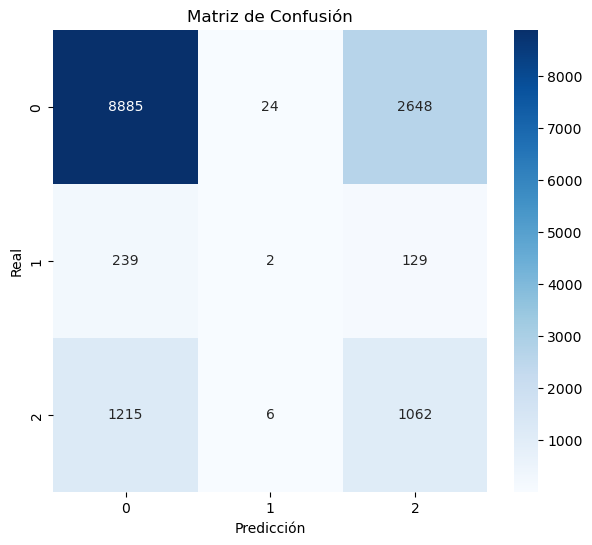

In [67]:
# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [68]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[8885,   24, 2648],
       [ 239,    2,  129],
       [1215,    6, 1062]])

In [43]:
importance_gain = model.get_score(importance_type="gain")

importance_df = (
    pd.DataFrame(
        importance_gain.items(),
        columns=["feature", "gain"]
    )
    .sort_values(by="gain", ascending=False)
)

print(importance_df)

                      feature        gain
57                num_proceso  175.762650
66                   apartado  116.434814
75           tipo_adquisicion   56.722198
59           unidad_ejecutora   51.715202
68  etapa_autorizacion_pliego   34.810947
..                        ...         ...
64            tipo_doc_compra    1.969707
55              TOT_VIDRIERIA    1.891466
54        TOT_PROD_DEPORTIVOS    1.863551
35              TOT_INMUEBLES    1.740445
65              requiere_pago    1.352989

[76 rows x 2 columns]


In [58]:
importance_df.to_csv(ruta+'importancia_xgboost_M.csv')

In [52]:
# Copia para no pisar el df original
df_test_pred = df_test.copy()
df_test_pred['target'] = y_test
# Agregar la clase predicha
df_test_pred["xgb_pred_class"] = y_pred

# Agregar la probabilidad de cada clase
df_test_pred["xgb_prob_class_M1_0"] = pred_prob[:, 0]
df_test_pred["xgb_prob_class_M1_1"] = pred_prob[:, 1]
df_test_pred["xgb_prob_class_M1_2"] = pred_prob[:, 2]

df_test_pred.head()

,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,...,genera_recursos,financiamiento_externo,acepta_prorroga,cat_inicio_contrato,tipo_adquisicion,target,xgb_pred_class,xgb_prob_class_M1_0,xgb_prob_class_M1_1,xgb_prob_class_M1_2
55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.721647,0.003294,0.275058
55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.753516,0.002544,0.243940
55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,30.0,...,No,No,No,A partir del perfeccionamiento del documento c...,MIXTO,0,0,0.809063,0.000722,0.190215
55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,360.0,...,No,No,Sí,Entre los 10 primeros Días del mes siguiente d...,SERVICIO,0,0,0.587880,0.007950,0.404170
55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,360.0,...,No,No,No,Dentro de los 10 Días del perfeccionamiento de...,SERVICIO,0,0,0.777471,0.010338,0.212191


In [53]:
df_test_pred.to_csv(ruta+'resultado_XGboost_1.csv')

### Modelo con variables métricas de grafos

In [20]:
df_target = df[['num_proceso','target', 'targetB']]
df_metricas = metricas.merge(df_target, on=["num_proceso"], how="left")


In [21]:
df_propiedades_grafo = df_metricas

In [22]:
df_train_metricas = df_train.merge(df_propiedades_grafo, on="num_proceso", how="left")
df_test_metricas = df_test.merge(df_propiedades_grafo, on="num_proceso", how="left")
df_train_metricas = df_train_metricas.drop('num_proceso',axis=1)
df_test_metricas = df_test_metricas.drop('num_proceso',axis=1)
df_train_metricas = df_train_metricas.drop('target',axis=1)
df_test_metricas = df_test_metricas.drop('target',axis=1)
df_train_metricas = df_train_metricas.drop('targetB',axis=1)
df_test_metricas = df_test_metricas.drop('targetB',axis=1)

In [23]:
#XGBoost incluye su propia clase para almacenar conjuntos de datos, llamada DMatrix. 
#Es una clase muy optimizada en cuanto a memoria y velocidad. 
#Por eso, convertir conjuntos de datos a este formato es un requisito para la API nativa de XGBoost

dtrain = xgb.DMatrix(
    df_train_metricas,
    label=y_train,
    weight=sample_weights,
    enable_categorical=True
)

dtest = xgb.DMatrix(
    df_test_metricas,
    label=y_test,
    enable_categorical=True
)

In [26]:
best_score = np.inf
best_params = None

# Calcular total de combinaciones
total_trials = np.prod([len(v) for v in param_grid.values()])

print(f"Total de combinaciones a evaluar: {total_trials}")

trial = 0

for values in itertools.product(*param_grid.values()):
    trial += 1

    params = dict(zip(param_grid.keys(), values))
    params.update(base_params)

    print(f"\nEjecutando combinación {trial}/{total_trials}: {params}")

    try:
        cv_results = xgb.cv(
            params=params,
            dtrain=dtrain,
            num_boost_round=500,
            nfold=5,
            metrics=["mlogloss"],
            early_stopping_rounds=20,
            verbose_eval=False
        )
    except Exception as e:
        print(f"Error en combinación {params}: {e}")
        continue

    mean_mlogloss = cv_results["test-mlogloss-mean"].iloc[-1]

    print(f" → mlogloss = {mean_mlogloss:.5f}")

    if mean_mlogloss < best_score:
        best_score = mean_mlogloss
        best_params = params
        print("   *** Nuevo mejor modelo encontrado ***")

print("\n===================================")
print("Mejores parámetros:", best_params)
print("Mejor CV mlogloss:", best_score)


Total de combinaciones a evaluar: 96

Ejecutando combinación 1/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.65677
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 2/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.1, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.65654
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 3/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.3, 'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'eval_metric': 'mlogloss'}
 → mlogloss = 0.65656

Ejecutando combinación 4/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree'

In [27]:
best_params

{'max_depth': 3,
 'min_child_weight': 3,
 'subsample': 1.0,
 'colsample_bytree': 0.8,
 'eta': 0.05,
 'gamma': 0,
 'objective': 'multi:softprob',
 'num_class': 3,
 'tree_method': 'hist',
 'eval_metric': 'mlogloss'}

In [28]:
model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=500
)

[0]	train-mlogloss:1.06923	test-mlogloss:1.06543
[499]	train-mlogloss:0.37936	test-mlogloss:0.39023


In [29]:
#matriz de confusion
dtest = xgb.DMatrix(df_test_metricas, enable_categorical=True)
pred_prob = model.predict(dtest)
y_pred = np.argmax(pred_prob, axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[10869   223   465]
 [   39   181   150]
 [  514   419  1350]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     11557
           1       0.22      0.49      0.30       370
           2       0.69      0.59      0.64      2283

    accuracy                           0.87     14210
   macro avg       0.62      0.67      0.63     14210
weighted avg       0.89      0.87      0.88     14210



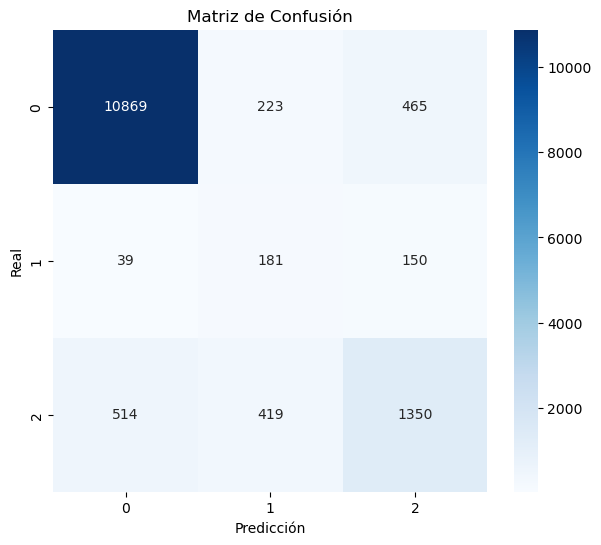

In [30]:
# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [31]:
#importancia de variables

importance_gain = model.get_score(importance_type="gain")

importance_df = (
    pd.DataFrame(
        importance_gain.items(),
        columns=["feature", "gain"]
    )
    .sort_values(by="gain", ascending=False)
)

print(importance_df)
importance_df.to_csv(ruta+'importancia_xgboost_metricas.csv')

               feature        gain
69             p.grado  424.400879
59            apartado  191.797897
52    unidad_ejecutora   92.847313
65    tipo_adquisicion   78.854164
71          p.pagerank   76.223167
..                 ...         ...
18            TOT_CINE    6.016232
50      TOT_VIGILANCIA    5.337976
28    TOT_HERRAMIENTAS    4.683097
25  TOT_EQUIPO_MILITAR    4.497363
49       TOT_VIDRIERIA    0.741103

[73 rows x 2 columns]


In [32]:
### guardar resultados
# Copia para no pisar el df original
df_test_pred = df_test.copy()
df_test_pred['target'] = y_test
# Agregar la clase predicha
df_test_pred["xgb_pred_classMMG"] = y_pred

# Agregar la probabilidad de cada clase
df_test_pred["xgb_prob_class_MMG1_0"] = pred_prob[:, 0]
df_test_pred["xgb_prob_class_MMG1_1"] = pred_prob[:, 1]
df_test_pred["xgb_prob_class_MMG1_2"] = pred_prob[:, 2]

df_test_pred.head()

,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,...,genera_recursos,financiamiento_externo,acepta_prorroga,cat_inicio_contrato,tipo_adquisicion,target,xgb_pred_classMMG,xgb_prob_class_MMG1_0,xgb_prob_class_MMG1_1,xgb_prob_class_MMG1_2
55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.873991,0.004885,0.121125
55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.855046,0.002294,0.142660
55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,30.0,...,No,No,No,A partir del perfeccionamiento del documento c...,MIXTO,0,0,0.691569,0.003828,0.304602
55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,360.0,...,No,No,Sí,Entre los 10 primeros Días del mes siguiente d...,SERVICIO,0,0,0.864624,0.003144,0.132232
55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,360.0,...,No,No,No,Dentro de los 10 Días del perfeccionamiento de...,SERVICIO,0,0,0.922565,0.002532,0.074902


In [33]:
df_test_pred.to_csv(ruta+'resultado_xgboost_MMG.csv')

### Modelo con target binario

In [34]:
#probar con target binario
y_train = y_train.replace(2, 1)
y_test  = y_test.replace(2, 1)

In [35]:
y_train

0        0
1        1
2        0
3        0
4        0
        ..
55471    1
55472    1
55473    1
55474    1
55475    1
Name: target, Length: 55476, dtype: int64

In [36]:
#Como las clases son desbalanceadas
#se Calculan los pesos inversamente proporcionales a la frecuencia
class_counts = y_train.value_counts()
total = len(y_train)

class_weights = {}
for c, count in class_counts.items():
    weight = total / (len(class_counts) * count)

    # Multiplicar peso de clases 1 y 2 por 
    if c in [1, 2]:
        weight *= 1.1

    class_weights[c] = weight
        
#Pasar los pesos a cada fila
sample_weights = y_train.map(class_weights)

class_weights

{0: 0.6449947680502267, 1: 2.4466201587683427}

In [37]:
#XGBoost incluye su propia clase para almacenar conjuntos de datos, llamada DMatrix. 
#Es una clase muy optimizada en cuanto a memoria y velocidad. 
#Por eso, convertir conjuntos de datos a este formato es un requisito para la API nativa de XGBoost

dtrain = xgb.DMatrix(
    df_train,
    label=y_train,
    weight=sample_weights,
    enable_categorical=True
)

dtest = xgb.DMatrix(
    df_test,
    label=y_test,
    enable_categorical=True
)


In [38]:
param_grid = {
    "max_depth":[3, 5], # [3, 4, 5] Profundidad máxima de los árboles.
    "min_child_weight": [1, 3, ], # [1, 3, 5] #Mínima suma de pesos (o número de instancias) necesaria para hacer un split.
    "subsample": [ 0.8, 1.0],#[0.6, 0.8, 1.0] Porcentaje de filas usadas en cada árbol.
    "colsample_bytree": [0.8, 1.0],#[0.6, 0.8, 1.0] Porcentaje de columnas usadas en cada árbol.
    "eta": [ 0.05, 0.1], #[0.01, 0.05, 0.1] #Qué tan rápido “aprende” el modelo. learning rate
    "gamma": [0, 0.1, 0.3] #Requerimiento mínimo de reducción de pérdida para permitir un split
}

base_params = {
    "objective": "binary:logistic",   # salida: probabilidad de clase 1
    "tree_method": "hist",
    "eval_metric": "logloss"
}

In [39]:
best_score = np.inf
best_params = None

total_trials = np.prod([len(v) for v in param_grid.values()])
print(f"Total de combinaciones a evaluar: {total_trials}")

trial = 0

for values in itertools.product(*param_grid.values()):
    trial += 1

    params = dict(zip(param_grid.keys(), values))
    params.update(base_params)

    print(f"\nEjecutando combinación {trial}/{total_trials}: {params}")

    try:
        cv_results = xgb.cv(
            params=params,
            dtrain=dtrain,
            num_boost_round=500,
            nfold=5,
            metrics=["logloss"],
            early_stopping_rounds=20,
            verbose_eval=False
        )
    except Exception as e:
        print(f"Error en combinación {params}: {e}")
        continue

    mean_logloss = cv_results["test-logloss-mean"].iloc[-1]

    print(f" → logloss = {mean_logloss:.5f}")

    if mean_logloss < best_score:
        best_score = mean_logloss
        best_params = params
        print("   *** Nuevo mejor modelo encontrado ***")

print("\n===================================")
print("Mejores parámetros:", best_params)
print("Mejor CV logloss:", best_score)

Total de combinaciones a evaluar: 96

Ejecutando combinación 1/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0, 'objective': 'binary:logistic', 'tree_method': 'hist', 'eval_metric': 'logloss'}
 → logloss = 0.63283
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 2/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.1, 'objective': 'binary:logistic', 'tree_method': 'hist', 'eval_metric': 'logloss'}
 → logloss = 0.63262
   *** Nuevo mejor modelo encontrado ***

Ejecutando combinación 3/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0.3, 'objective': 'binary:logistic', 'tree_method': 'hist', 'eval_metric': 'logloss'}
 → logloss = 0.63295

Ejecutando combinación 4/96: {'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'eta': 0.1, 'gamma': 0, 'objective': 'binary

In [40]:
best_params

{'max_depth': 5,
 'min_child_weight': 3,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'eta': 0.05,
 'gamma': 0.1,
 'objective': 'binary:logistic',
 'tree_method': 'hist',
 'eval_metric': 'logloss'}

In [41]:
model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=50
)


[0]	train-logloss:0.68787	test-logloss:0.71980
[50]	train-logloss:0.61966	test-logloss:0.63628
[100]	train-logloss:0.60045	test-logloss:0.61055
[150]	train-logloss:0.58860	test-logloss:0.60316
[200]	train-logloss:0.57915	test-logloss:0.59226
[250]	train-logloss:0.57064	test-logloss:0.58390
[300]	train-logloss:0.56247	test-logloss:0.57302
[350]	train-logloss:0.55548	test-logloss:0.56799
[400]	train-logloss:0.54899	test-logloss:0.56034
[450]	train-logloss:0.54323	test-logloss:0.55023
[499]	train-logloss:0.53765	test-logloss:0.54768


In [42]:
dtest = xgb.DMatrix(df_test, enable_categorical=True)
pred_prob = model.predict(dtest)

# convertir prob a clase 0/1
y_pred = (pred_prob >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[8900 2657]
 [1377 1276]]
              precision    recall  f1-score   support

           0       0.87      0.77      0.82     11557
           1       0.32      0.48      0.39      2653

    accuracy                           0.72     14210
   macro avg       0.60      0.63      0.60     14210
weighted avg       0.76      0.72      0.74     14210



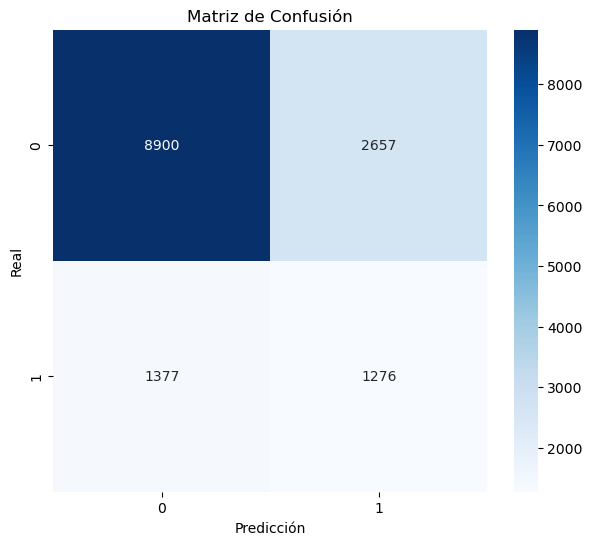

In [43]:
# 1. Predicciones de probabilidad
dtest = xgb.DMatrix(df_test, enable_categorical=True)
pred_prob = model.predict(dtest)

# 2. Convertir a clase (0/1)
y_pred = (pred_prob > 0.5).astype(int)

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [44]:
importance_gain = model.get_score(importance_type="gain")

importance_df = (
    pd.DataFrame(
        importance_gain.items(),
        columns=["feature", "gain"]
    )
    .sort_values(by="gain", ascending=False)
)

print(importance_df)

                               feature       gain
71                    tipo_adquisicion  38.151047
56                    unidad_ejecutora  35.132320
57  servicio_administrativo_financiero  24.234200
24                        TOT_LIMPIEZA  23.655247
63                            apartado  17.351694
..                                 ...        ...
60                          cotizacion   6.320731
67                 etapa_acto_apertura   6.268408
66          etapa_autorizacion_llamado   5.890967
69                     acepta_prorroga   5.707614
68                     genera_recursos   1.574339

[72 rows x 2 columns]


In [45]:
importance_df.to_csv(ruta+'importancia_xgboost_binario.csv')

In [46]:
# Copia para no pisar el df original
df_test_pred = df_test.copy()

# Target real
df_test_pred["target"] = y_test

# Clase predicha
df_test_pred["xgb_pred_class"] = y_pred

# Probabilidad clase positiva (1)
df_test_pred["xgb_prob_class_1"] = pred_prob

# Probabilidad clase negativa (0)
df_test_pred["xgb_prob_class_0"] = 1 - pred_prob

df_test_pred.head()

,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,...,etapa_acto_apertura,genera_recursos,financiamiento_externo,acepta_prorroga,cat_inicio_contrato,tipo_adquisicion,target,xgb_pred_class,xgb_prob_class_1,xgb_prob_class_0
55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,sin datos,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.389513,0.610487
55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,90.0,...,sin datos,No,No,No,A partir del perfeccionamiento del documento c...,BIEN,0,0,0.340346,0.659654
55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,30.0,...,sin datos,No,No,No,A partir del perfeccionamiento del documento c...,MIXTO,0,0,0.226924,0.773076
55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,360.0,...,Acto de apertura,No,No,Sí,Entre los 10 primeros Días del mes siguiente d...,SERVICIO,0,1,0.565900,0.434100
55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,360.0,...,Acto de apertura,No,No,No,Dentro de los 10 Días del perfeccionamiento de...,SERVICIO,0,0,0.208254,0.791746


In [47]:
df_test_pred.to_csv(ruta+'resultado_xgboost_binario.csv')